# Exploratory Data Analysis (EDA) - Time-Binned Geomagnetic Activity Dataset

## Project Context
`time_binned_dataset.csv` puts every data source (OMNI solar wind, GOES flares, DONKI CMEs)
on a single regular 3-hour clock and frames the problem as time-series forecasting:
*given the recent history of solar-wind conditions, what will geomagnetic activity (`ap`)
be some hours from now?* It's built by `notebooks/time_binned_dataset.ipynb`, which already
bakes in leakage guardrails (trailing-only rolling windows, forward-shifted target,
forward-fill-only gap handling). This notebook explores the **result** of that build:
distributions, sparsity, target imbalance, and correlations, to inform modeling choices
downstream.

**Columns** (35 features + target, indexed by 3h datetime bin):
- Five physical quantities (`bz_gsm_nt`, `b_magnitude_avg_nt`, `flow_speed_kms`,
  `proton_density_cm3`, `flow_pressure_npa`, `electric_field_mvpm`) each expanded into
  `_mean`, `_min`, `_max`, `_last`, `_trend` rolling stats over a 24h trailing window (30 cols).
- Sparse event counts/intensities: `flare_count_win`, `cme_count_win`, `flare_max_class_now`,
  `cme_max_speed_now`.
- `ap_now` (most recent observed `ap`, also the persistence-baseline input) and `ap_target`
  (the forecast target, `ap` some hours ahead).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Data Loading and Initial Inspection
Unlike the other datasets in this repo, the bin timestamp is the CSV's index (not a flat
time column), so we parse it directly as a `DatetimeIndex`.

In [2]:
data_path = "../data/time_binned_dataset.csv"

df = pd.read_csv(data_path, index_col=0, parse_dates=True)
df.index.name = "datetime"

print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns\n")
print("--- Column Info ---")
print(df.info())

Dataset Shape: 43,817 rows, 36 columns

--- Column Info ---
<class 'pandas.DataFrame'>
DatetimeIndex: 43817 entries, 2010-01-01 00:00:00 to 2024-12-30 00:00:00
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   bz_gsm_nt_mean             43810 non-null  float64
 1   bz_gsm_nt_min              43810 non-null  float64
 2   bz_gsm_nt_max              43810 non-null  float64
 3   bz_gsm_nt_last             43794 non-null  float64
 4   bz_gsm_nt_trend            43764 non-null  float64
 5   b_magnitude_avg_nt_mean    43810 non-null  float64
 6   b_magnitude_avg_nt_min     43810 non-null  float64
 7   b_magnitude_avg_nt_max     43810 non-null  float64
 8   b_magnitude_avg_nt_last    43796 non-null  float64
 9   b_magnitude_avg_nt_trend   43768 non-null  float64
 10  flow_speed_kms_mean        43810 non-null  float64
 11  flow_speed_kms_min         43810 non-null  float64
 12  flow_speed_kms_max

In [3]:
df.head()

,bz_gsm_nt_mean,bz_gsm_nt_min,bz_gsm_nt_max,bz_gsm_nt_last,bz_gsm_nt_trend,b_magnitude_avg_nt_mean,b_magnitude_avg_nt_min,b_magnitude_avg_nt_max,b_magnitude_avg_nt_last,b_magnitude_avg_nt_trend,...,electric_field_mvpm_min,electric_field_mvpm_max,electric_field_mvpm_last,electric_field_mvpm_trend,flare_count_win,cme_count_win,flare_max_class_now,cme_max_speed_now,ap_now,ap_target
datetime,,,,,,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,NaN,NaN,NaN,1.466667,NaN,NaN,NaN,NaN,3.000000,NaN,...,NaN,NaN,-0.413333,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2010-01-01 03:00:00,NaN,NaN,NaN,0.866667,NaN,NaN,NaN,NaN,2.966667,NaN,...,NaN,NaN,-0.240000,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2010-01-01 06:00:00,NaN,NaN,NaN,0.433333,NaN,NaN,NaN,NaN,2.766667,NaN,...,NaN,NaN,-0.123333,NaN,0.0,0.0,0.0,0.0,0.0,2.0
2010-01-01 09:00:00,0.958333,0.433333,1.466667,1.066667,NaN,2.966667,2.766667,3.133333,3.133333,NaN,...,-0.413333,-0.123333,-0.306667,NaN,0.0,0.0,0.0,0.0,0.0,2.0
2010-01-01 12:00:00,0.960000,0.433333,1.466667,0.966667,NaN,3.200000,2.766667,4.133333,4.133333,NaN,...,-0.413333,-0.123333,-0.280000,NaN,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Data Quality Check
This dataset is already gap-filled and leakage-guarded during construction (short gaps
forward-filled, rows with an incomplete window or missing target dropped). So instead of
cleaning from scratch, we verify that: no unexpected nulls remain, and the index is a
(near-)complete 3-hour grid with no duplicate timestamps.

In [4]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print("Missing values per column:")
print(nulls if not nulls.empty else "None")

print(f"\nDuplicate timestamps: {df.index.duplicated().sum()}")

expected_grid = pd.date_range(df.index.min(), df.index.max(), freq="3h")
missing_bins = expected_grid.difference(df.index)
print(f"Bins in [{df.index.min()}, {df.index.max()}] at 3h cadence: {len(expected_grid):,}")
print(f"Bins actually present: {len(df):,}  |  Missing bins: {len(missing_bins):,} "
      f"({len(missing_bins) / len(expected_grid):.2%})")

df.describe()

Missing values per column:
bz_gsm_nt_mean                 7
bz_gsm_nt_min                  7
bz_gsm_nt_max                  7
bz_gsm_nt_last                23
bz_gsm_nt_trend               53
b_magnitude_avg_nt_mean        7
b_magnitude_avg_nt_min         7
b_magnitude_avg_nt_max         7
b_magnitude_avg_nt_last       21
b_magnitude_avg_nt_trend      49
flow_speed_kms_mean            7
flow_speed_kms_min             7
flow_speed_kms_max             7
flow_speed_kms_last           35
flow_speed_kms_trend          75
proton_density_cm3_mean       46
proton_density_cm3_min        46
proton_density_cm3_max        46
proton_density_cm3_last       96
proton_density_cm3_trend     186
flow_pressure_npa_mean        46
flow_pressure_npa_min         46
flow_pressure_npa_max         46
flow_pressure_npa_last        96
flow_pressure_npa_trend      186
electric_field_mvpm_mean       7
electric_field_mvpm_min        7
electric_field_mvpm_max        7
electric_field_mvpm_last      38
electric_field_m


Duplicate timestamps: 0
Bins in [2010-01-01 00:00:00, 2024-12-30 00:00:00] at 3h cadence: 43,817
Bins actually present: 43,817  |  Missing bins: 0 (0.00%)


,bz_gsm_nt_mean,bz_gsm_nt_min,bz_gsm_nt_max,bz_gsm_nt_last,bz_gsm_nt_trend,b_magnitude_avg_nt_mean,b_magnitude_avg_nt_min,b_magnitude_avg_nt_max,b_magnitude_avg_nt_last,b_magnitude_avg_nt_trend,...,electric_field_mvpm_min,electric_field_mvpm_max,electric_field_mvpm_last,electric_field_mvpm_trend,flare_count_win,cme_count_win,flare_max_class_now,cme_max_speed_now,ap_now,ap_target
count,43810.000000,43810.000000,43810.000000,43794.000000,43764.000000,43810.000000,43810.000000,43810.000000,43796.000000,43768.000000,...,43810.000000,43810.000000,43779.000000,4.373600e+04,43817.000000,43817.000000,43817.00000,43817.000000,43817.000000,43817.000000
mean,-0.066401,-2.562141,2.437137,-0.066358,0.000249,5.554587,4.106922,7.288872,5.555092,0.000660,...,-1.011847,1.079242,0.033435,-3.726907e-05,2.772029,1.330420,0.54367,77.808438,8.596549,8.597531
std,1.624472,2.439826,2.431038,2.566073,3.517377,2.340237,1.668161,3.630450,2.760518,3.180544,...,1.088484,1.154268,1.114790,1.529814e+00,5.167082,1.718931,1.16053,220.173444,12.680833,12.680428
min,-16.412500,-31.833333,-12.933333,-31.833333,-31.766667,1.462500,0.600000,1.966667,0.600000,-44.433333,...,-17.376667,-4.226667,-17.376667,-2.596667e+01,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,-0.829167,-3.366667,0.966667,-1.300000,-1.666667,3.954167,2.966667,4.900000,3.766667,-1.366667,...,-1.349167,0.460000,-0.453333,-6.633333e-01,0.000000,0.000000,0.00000,0.000000,3.000000,3.000000
50%,-0.095833,-2.100000,1.933333,-0.100000,0.000000,5.050000,3.800000,6.366667,4.900000,-0.133333,...,-0.776667,0.853333,0.036667,1.665335e-16,0.000000,1.000000,0.00000,0.000000,5.000000,5.000000
75%,0.687500,-1.166667,3.300000,1.133333,1.633333,6.541667,4.933333,8.633333,6.566667,1.200000,...,-0.390000,1.406667,0.530000,6.733333e-01,4.000000,2.000000,0.00000,0.000000,9.000000,9.000000
max,13.958333,7.966667,26.900000,26.900000,37.900000,33.712500,22.566667,56.666667,56.666667,50.500000,...,7.146667,22.070000,22.070000,2.191000e+01,34.000000,13.000000,5.00000,3529.000000,400.000000,400.000000


**Observations:** The 3h grid is fully regular — 0 duplicate timestamps and 0 missing bins across the entire 2010-01-01 → 2024-12-30 span (43,817 of 43,817 expected bins present), so the build notebook's resampling didn't drop or fragment any time. Nulls do remain, though (contrary to what I'd assumed before running this) — between 7 and 186 rows per column, concentrated in `proton_density_cm3` and `flow_pressure_npa` (up to 186 nulls, the worst of the six quantities), which lines up with OMNI's plasma sensor having sparser coverage than its field sensor historically. Within each quantity, `_trend` has 2-4x more nulls than `_mean/_min/_max` — that's structural: `_trend` needs both the current bin and the bin 24h back, so a single missing bin anywhere in that pair propagates. At worst this is 186/43,817 = 0.4% of rows, so it's a "drop or impute before modeling" footnote, not a data-quality failure.

## 3. Feature Distributions (Rolling Stats)
30 of the 35 features are `{mean, min, max, last, trend}` of the same 6 underlying
solar-wind quantities over a 24h trailing window — so they come in **correlated groups of
five**. Don't expect 30 independently-shaped distributions; expect 6 distinct shapes,
each repeated across its 5 stats.

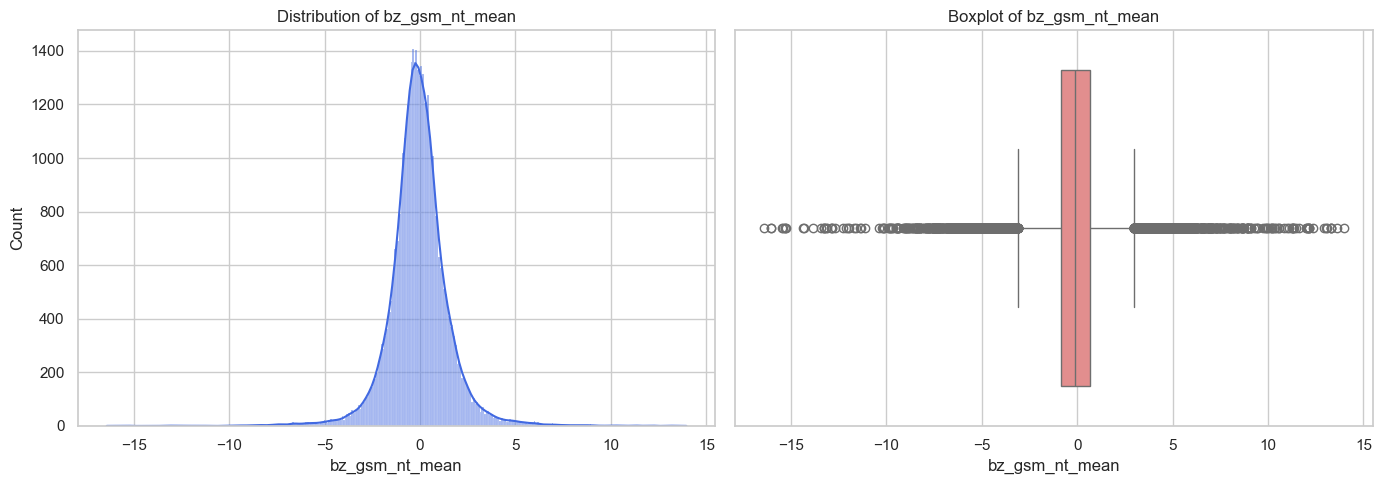

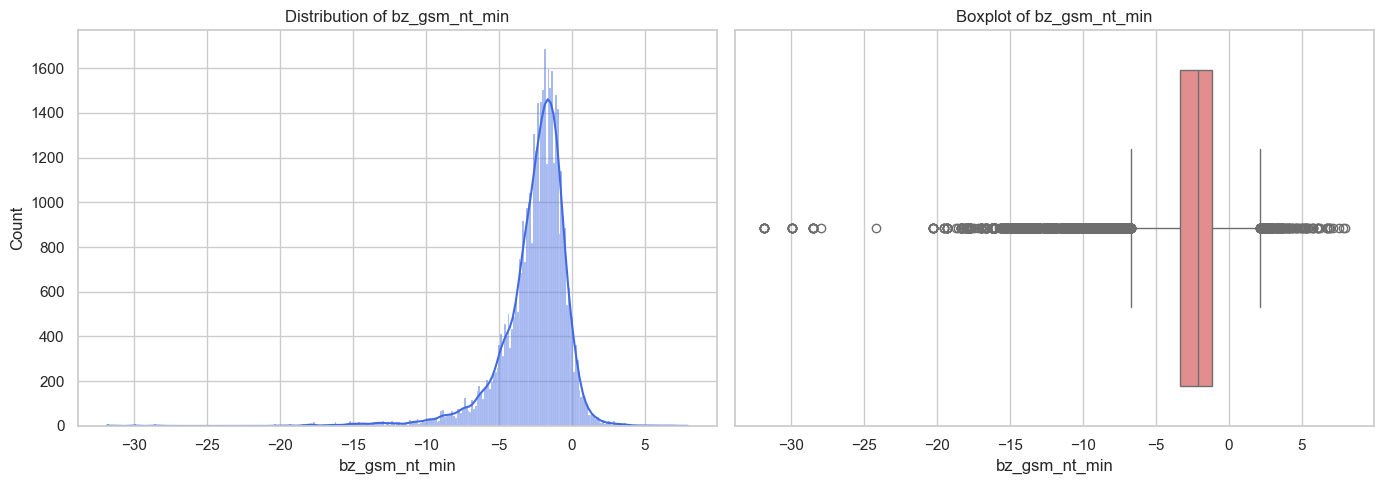

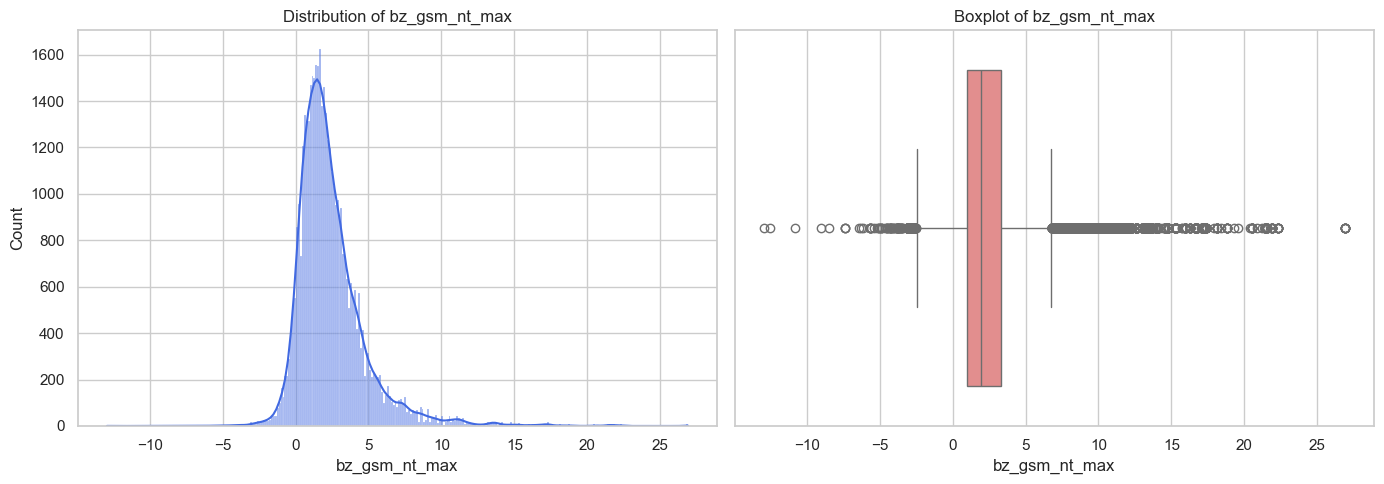

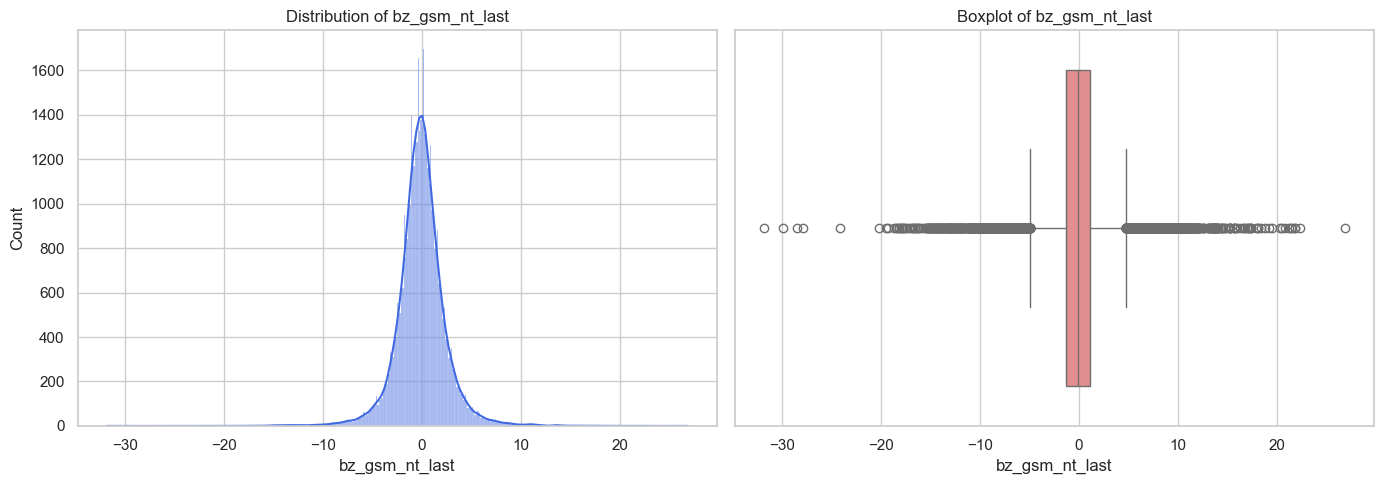

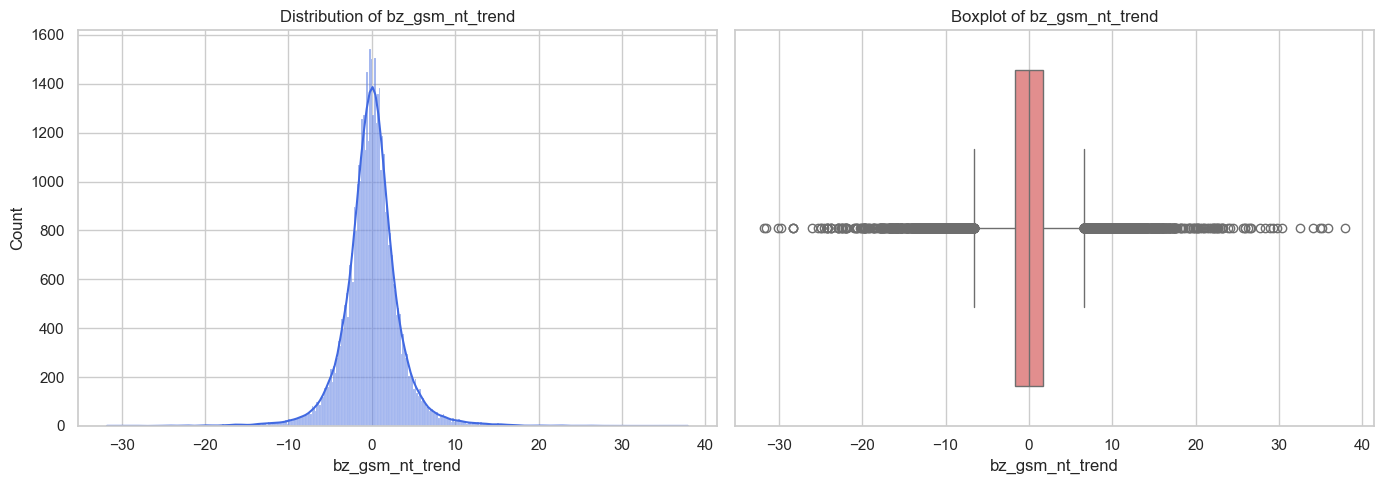

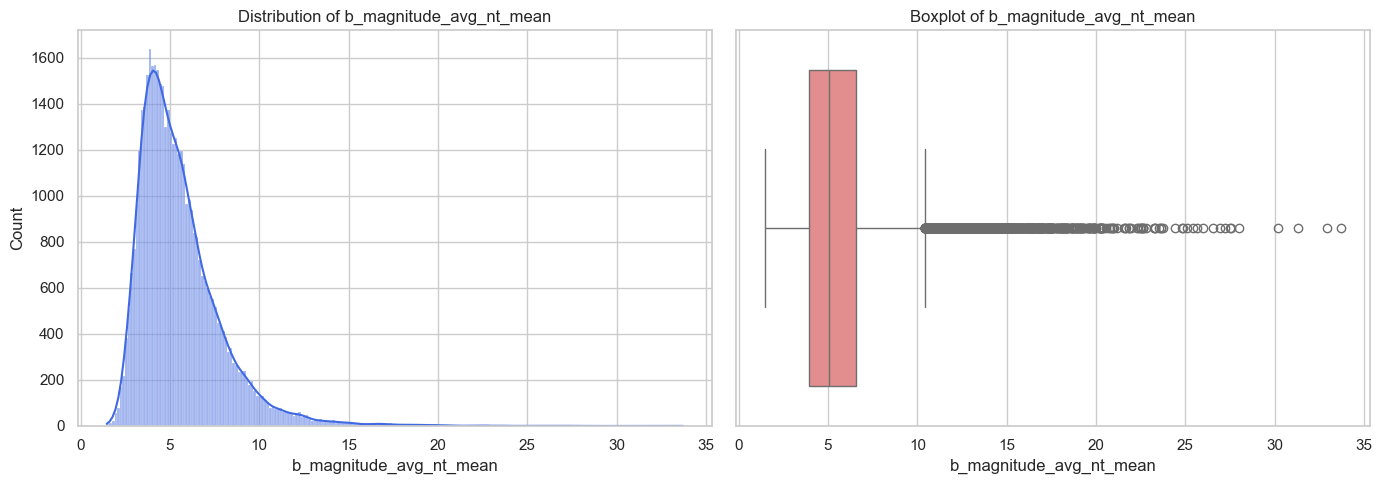

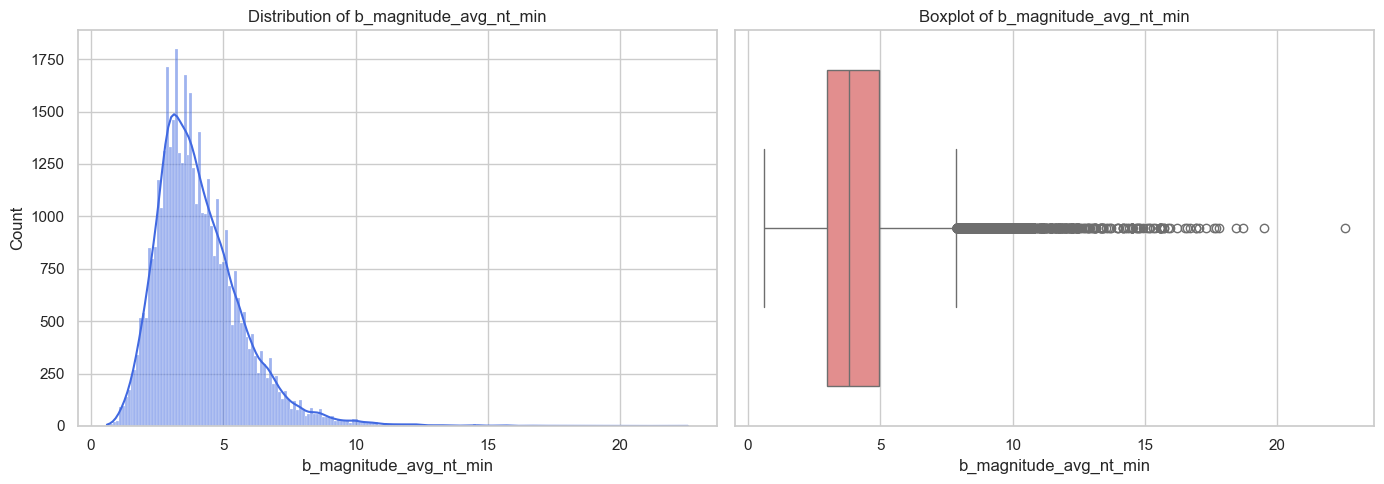

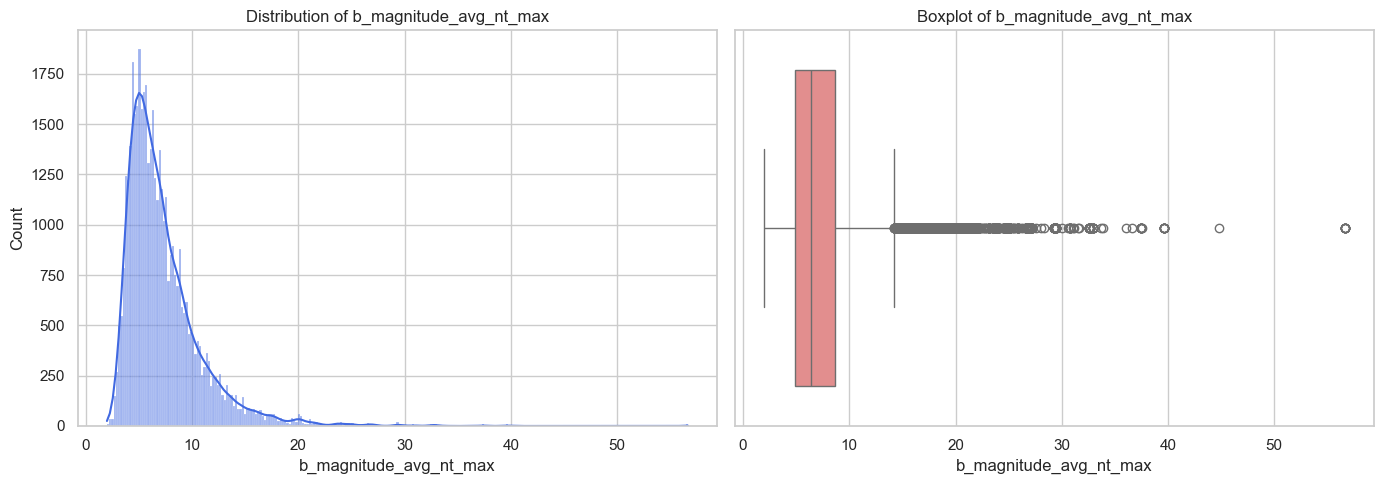

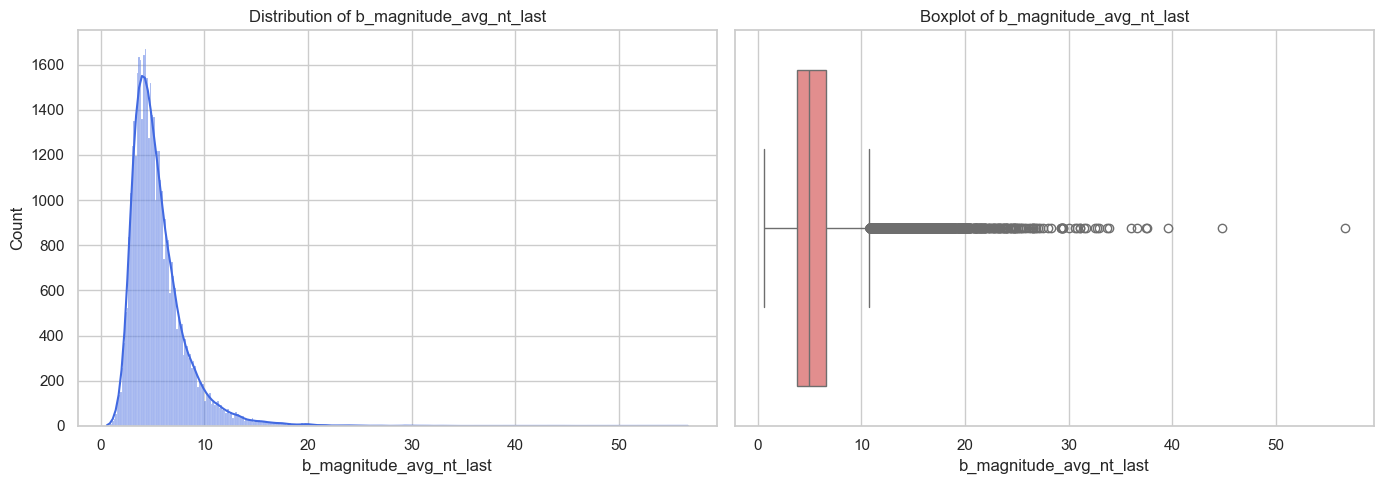

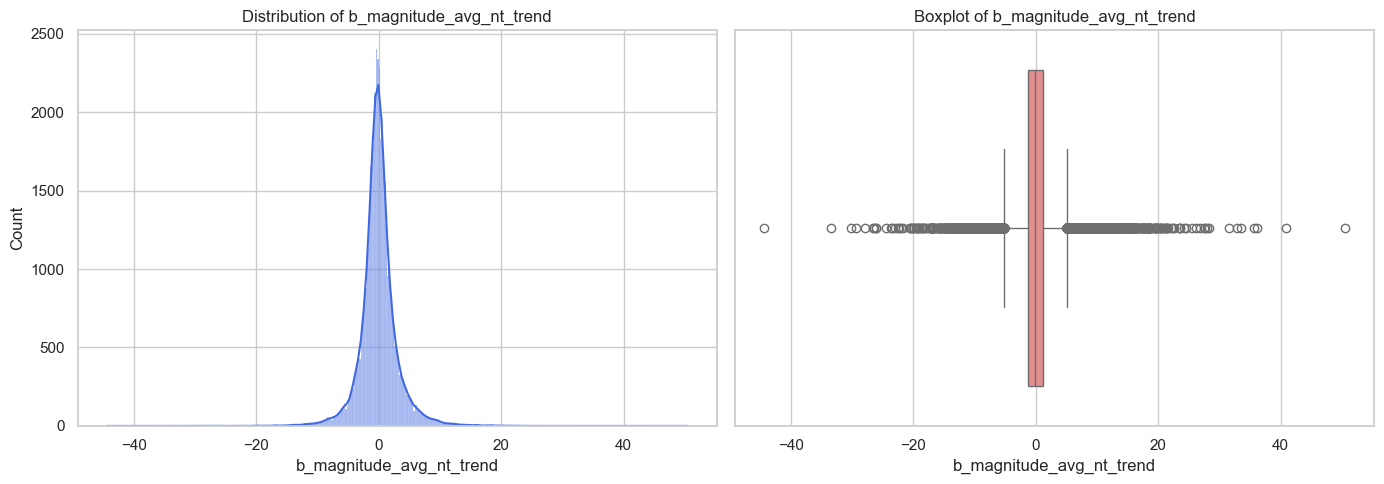

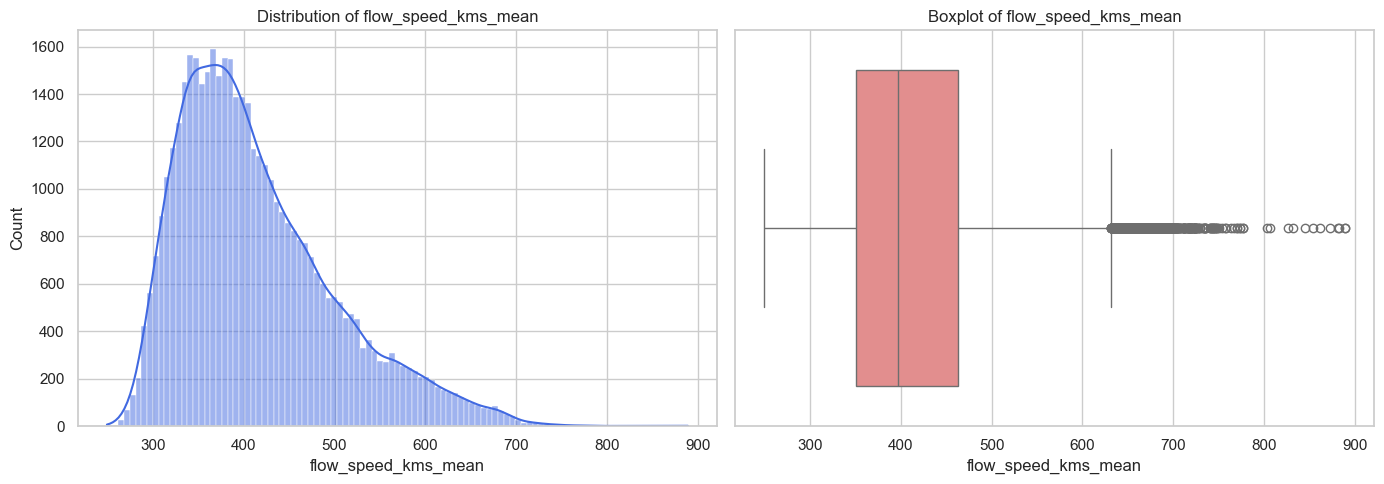

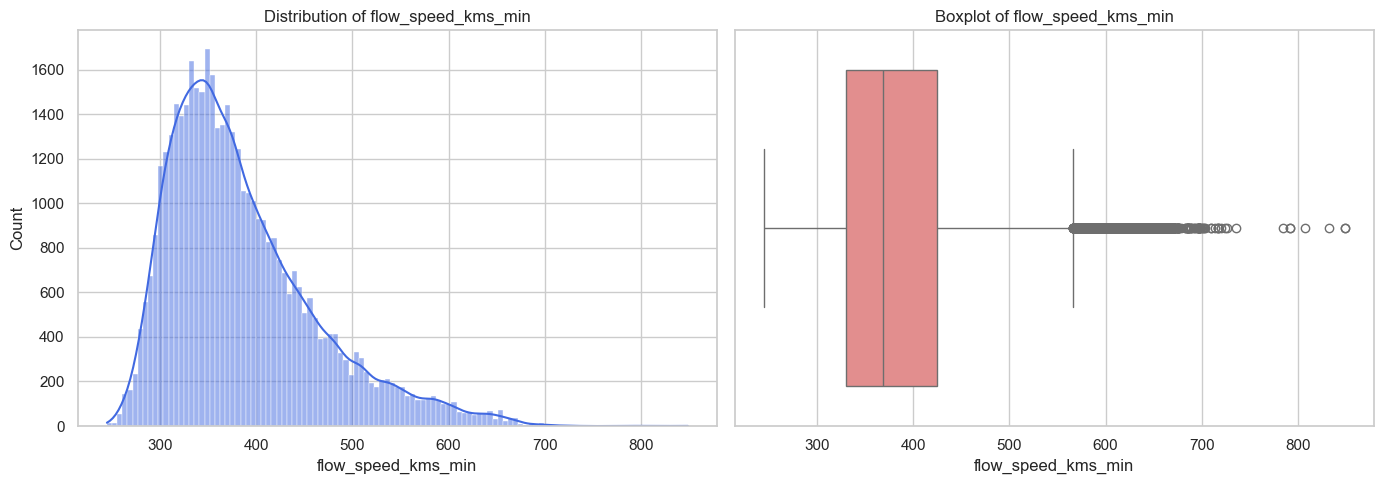

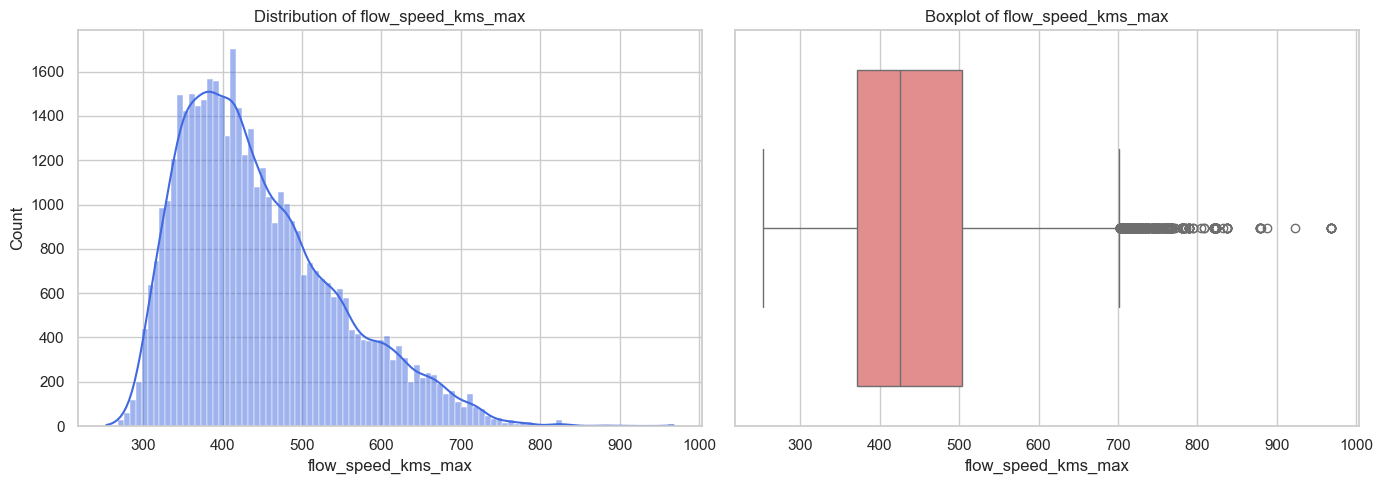

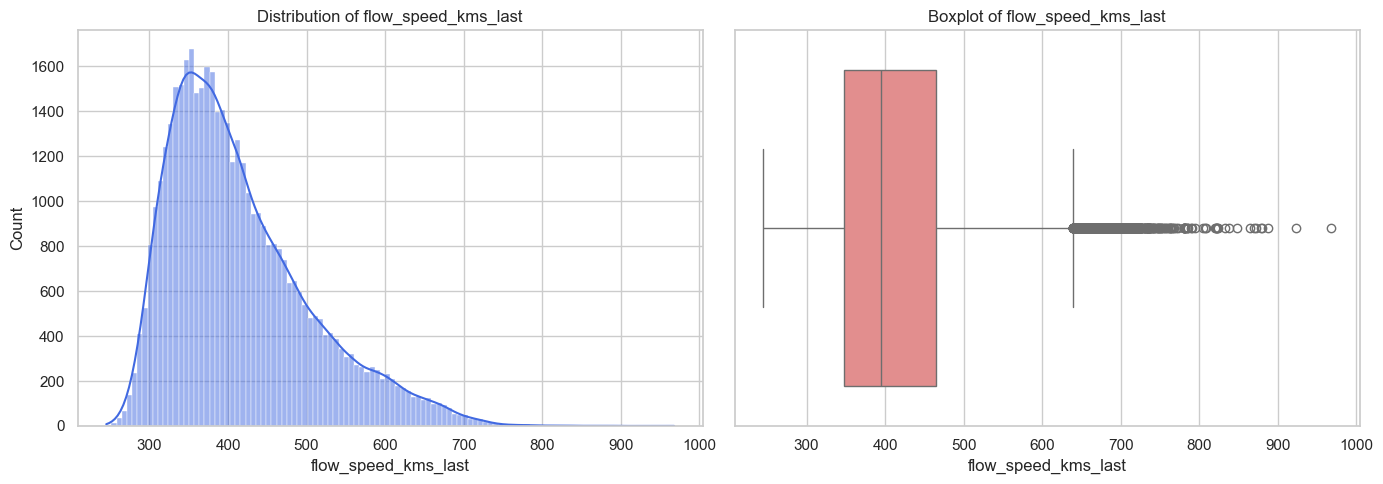

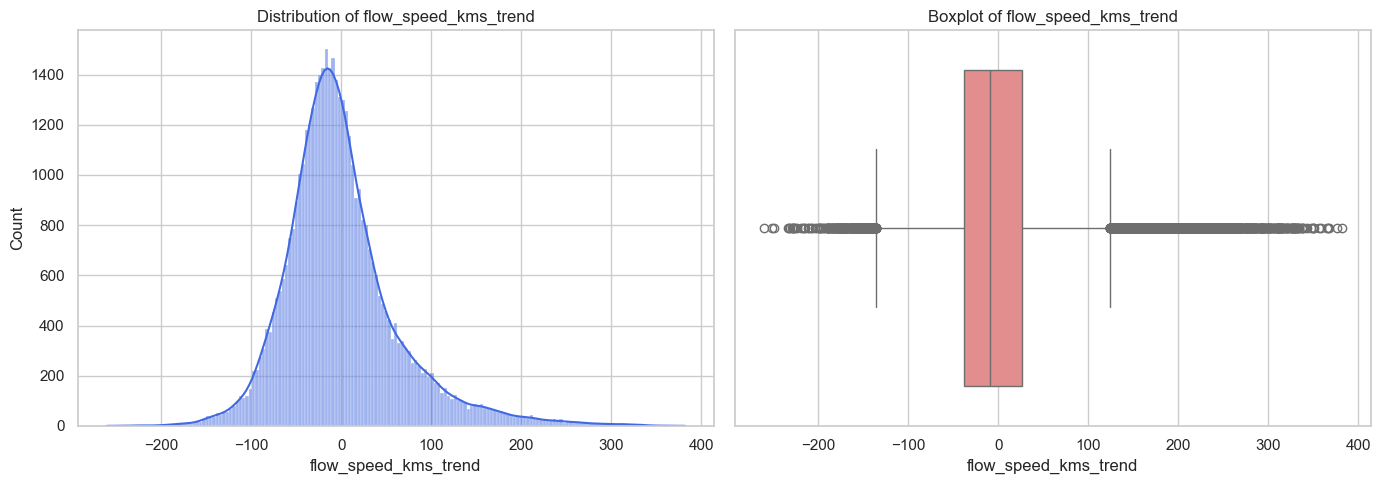

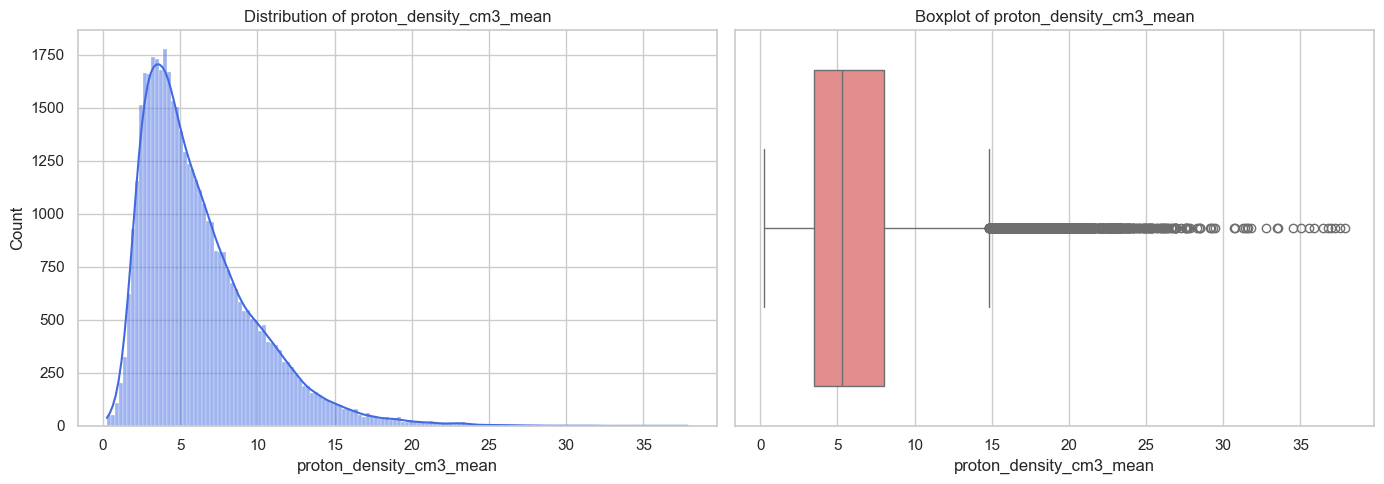

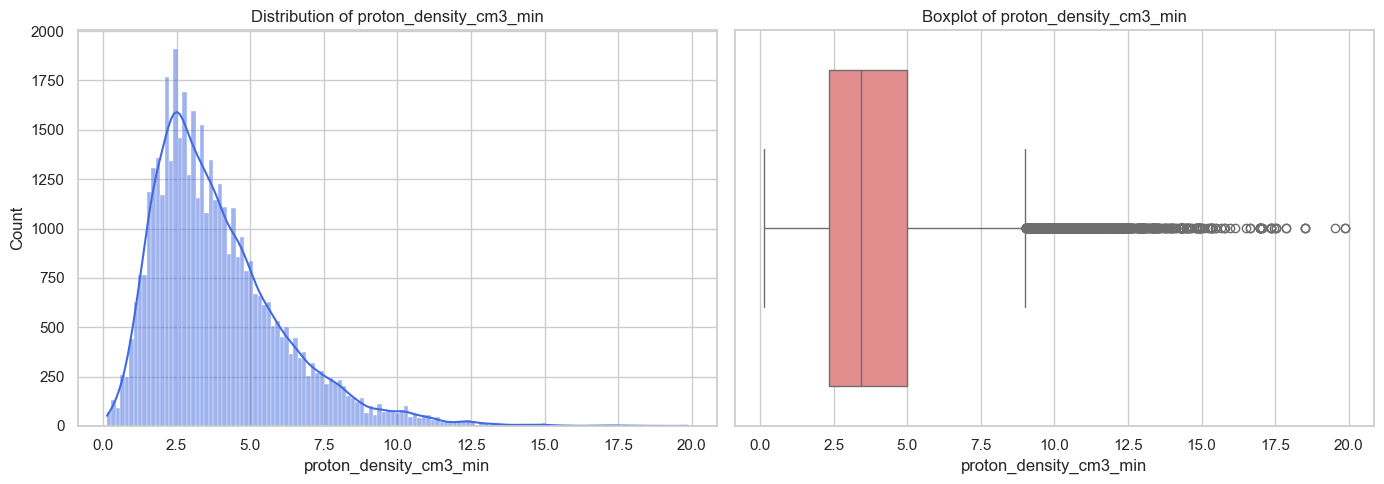

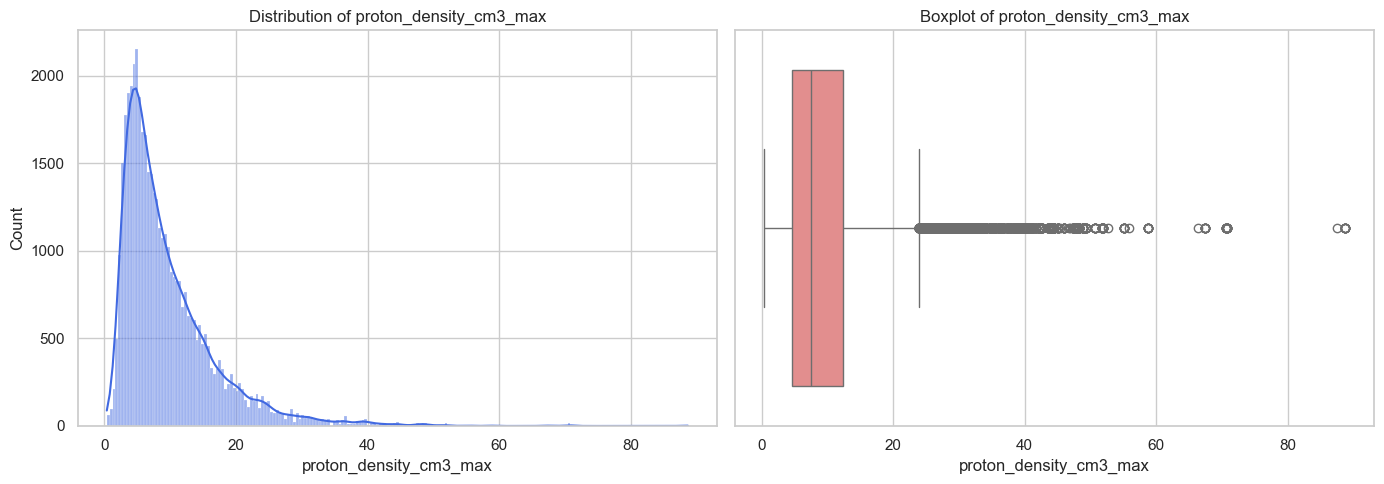

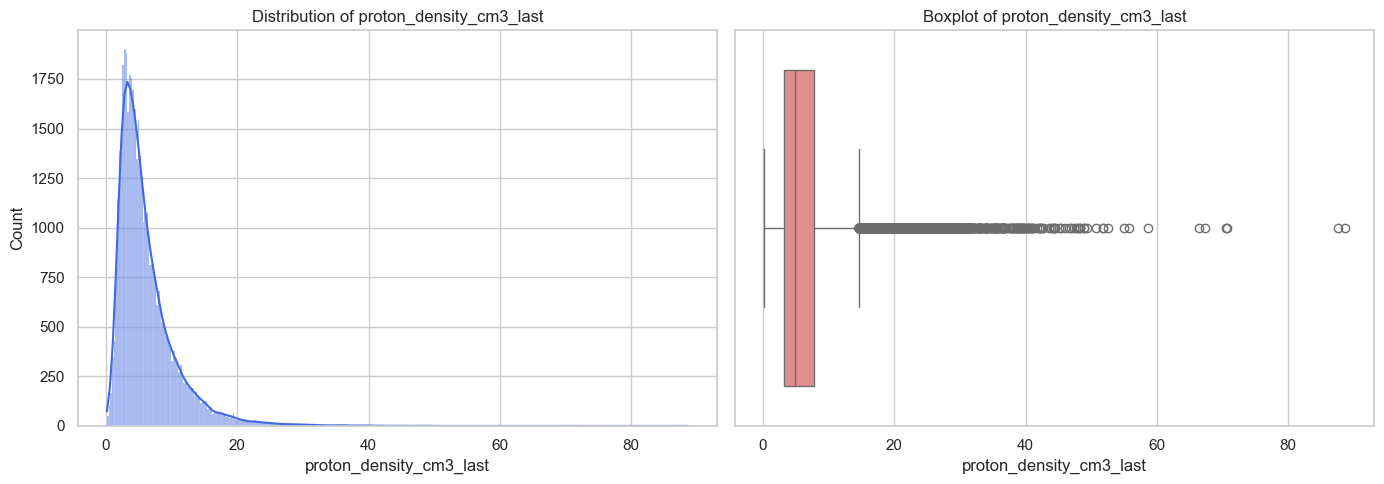

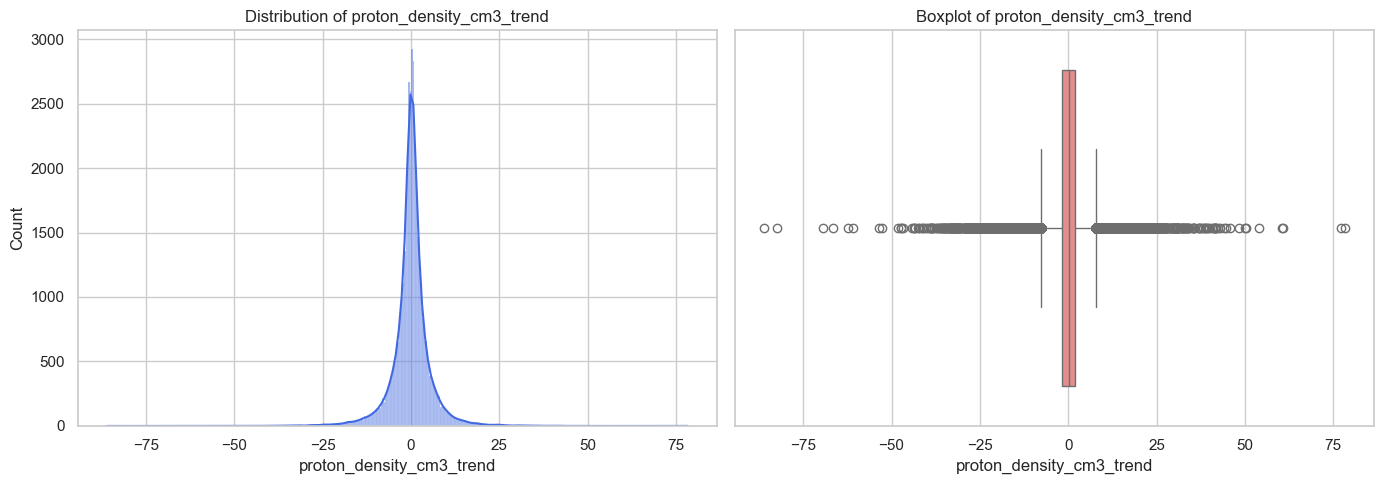

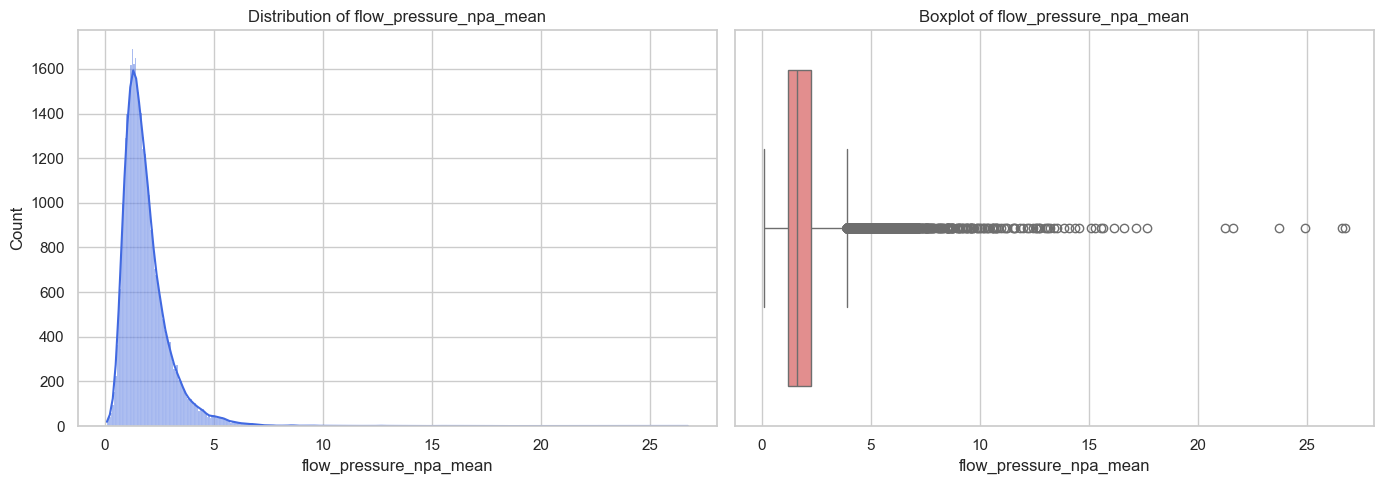

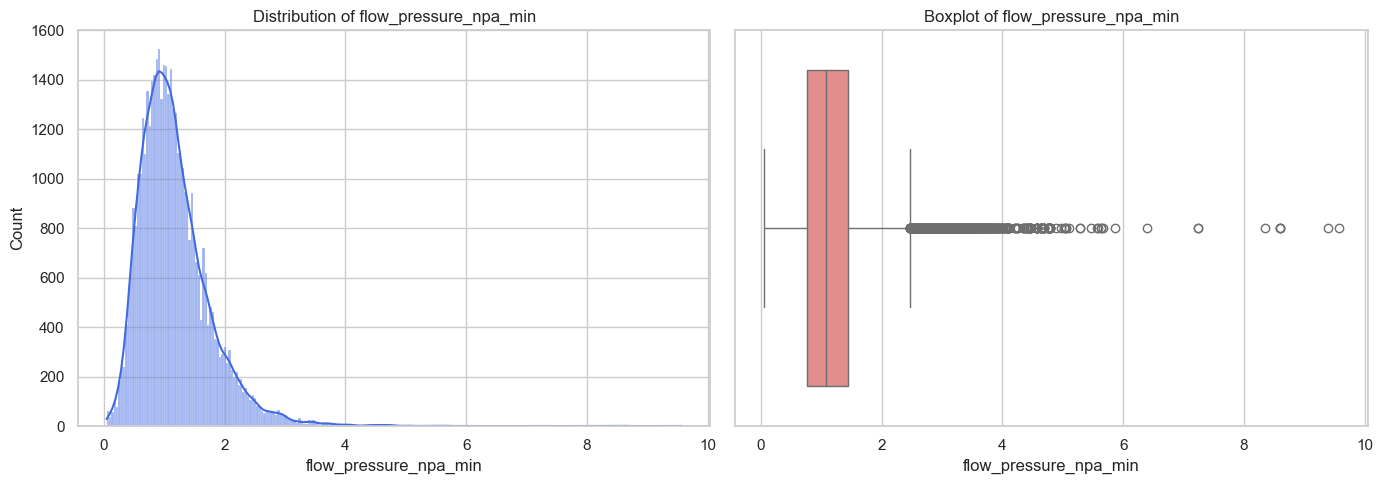

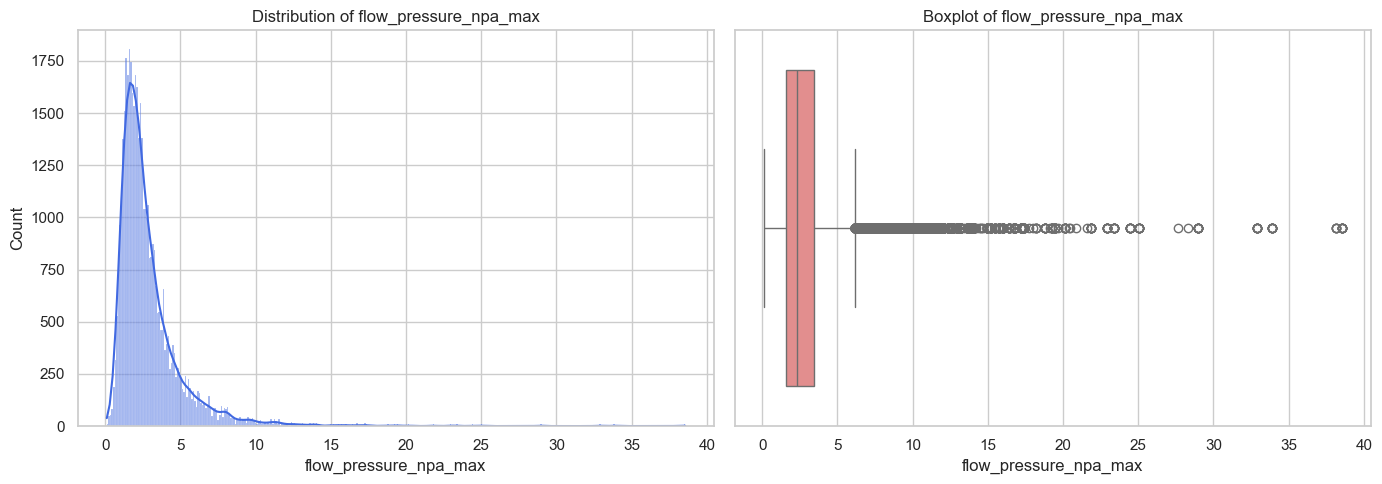

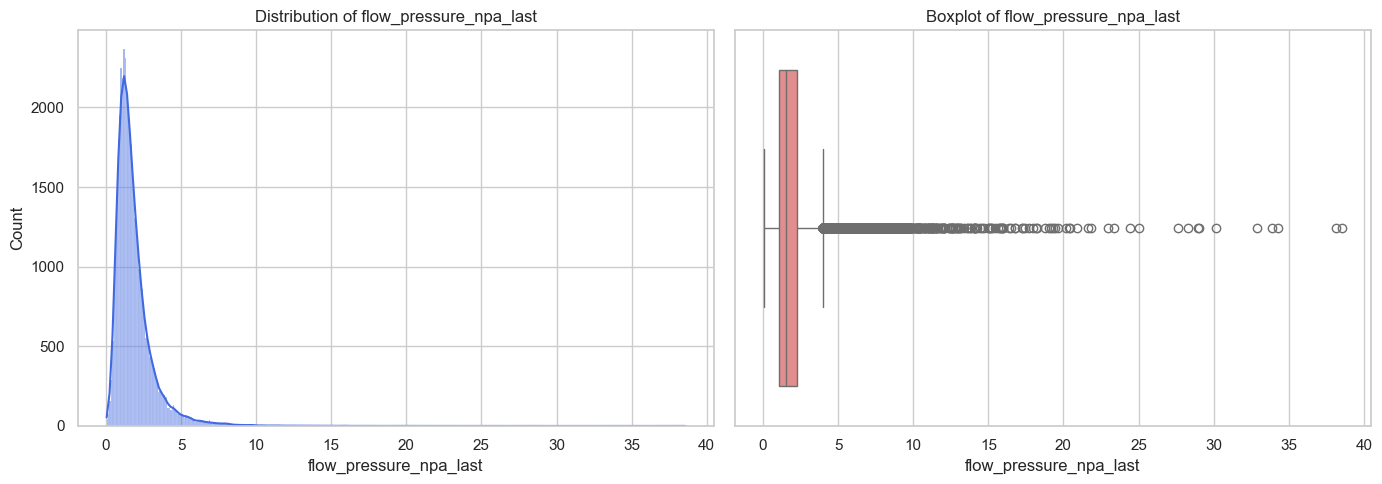

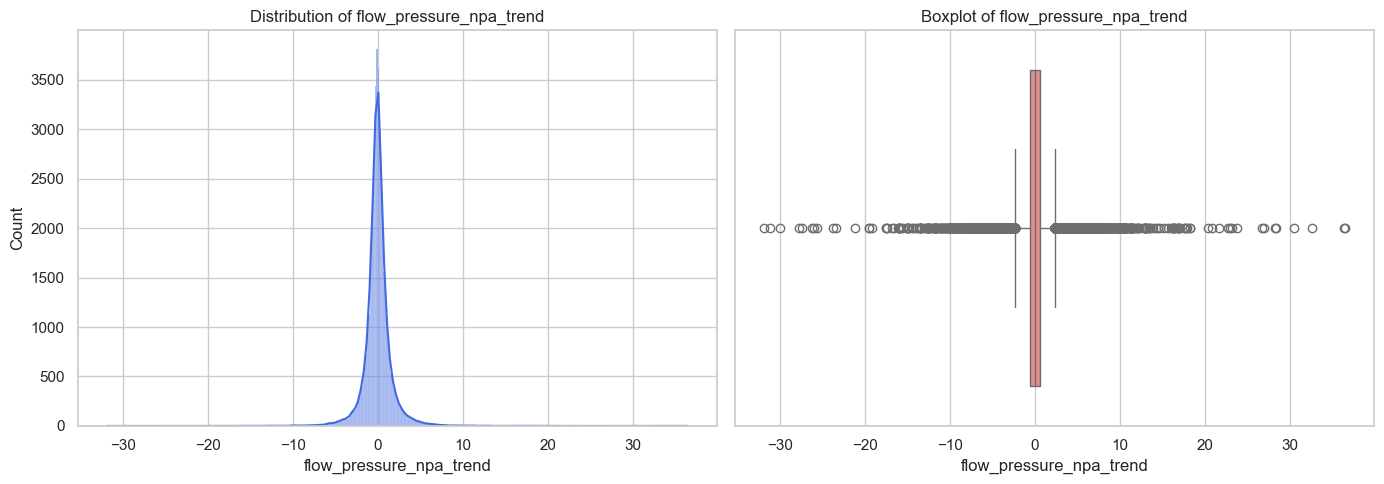

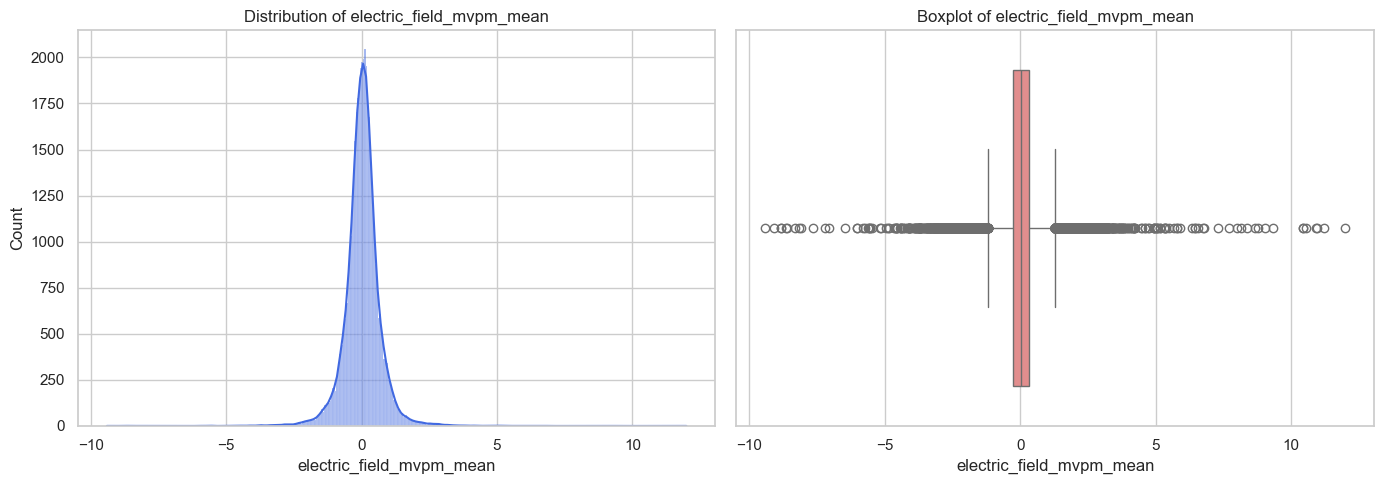

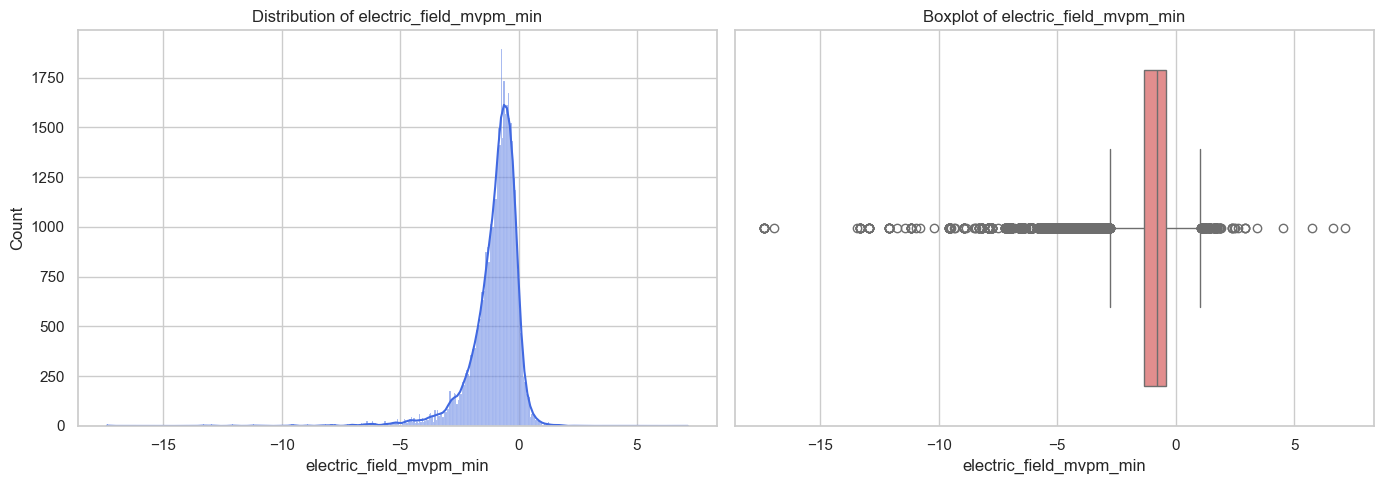

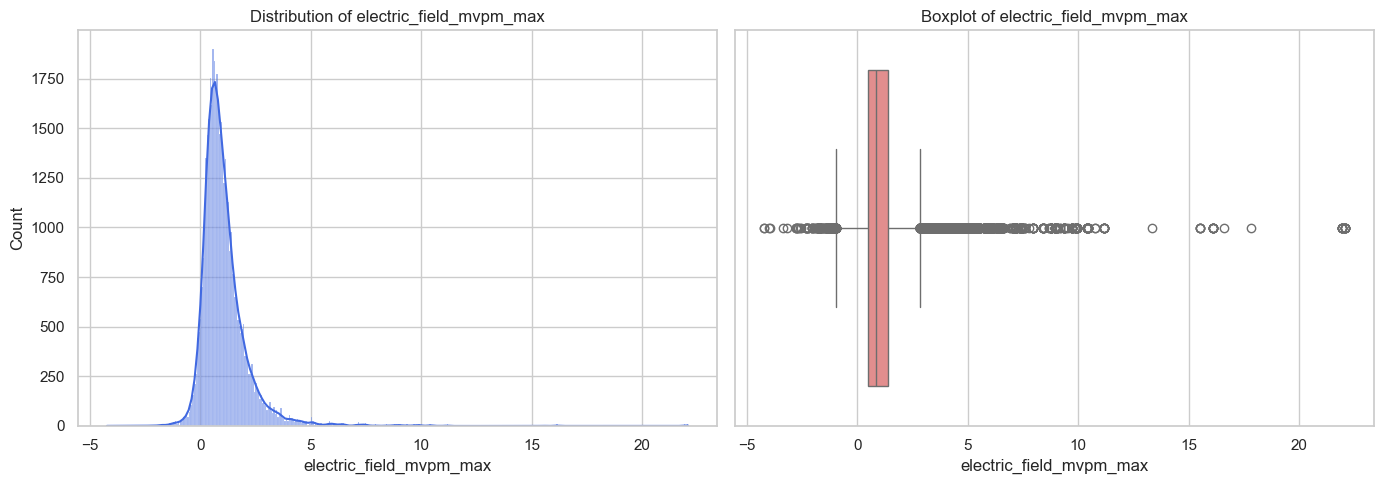

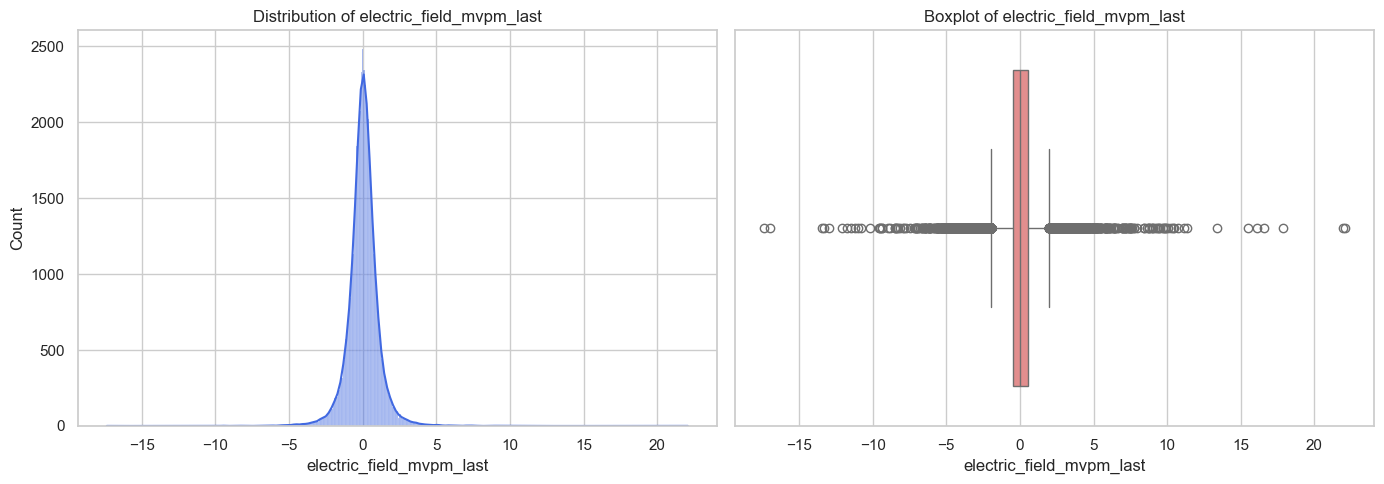

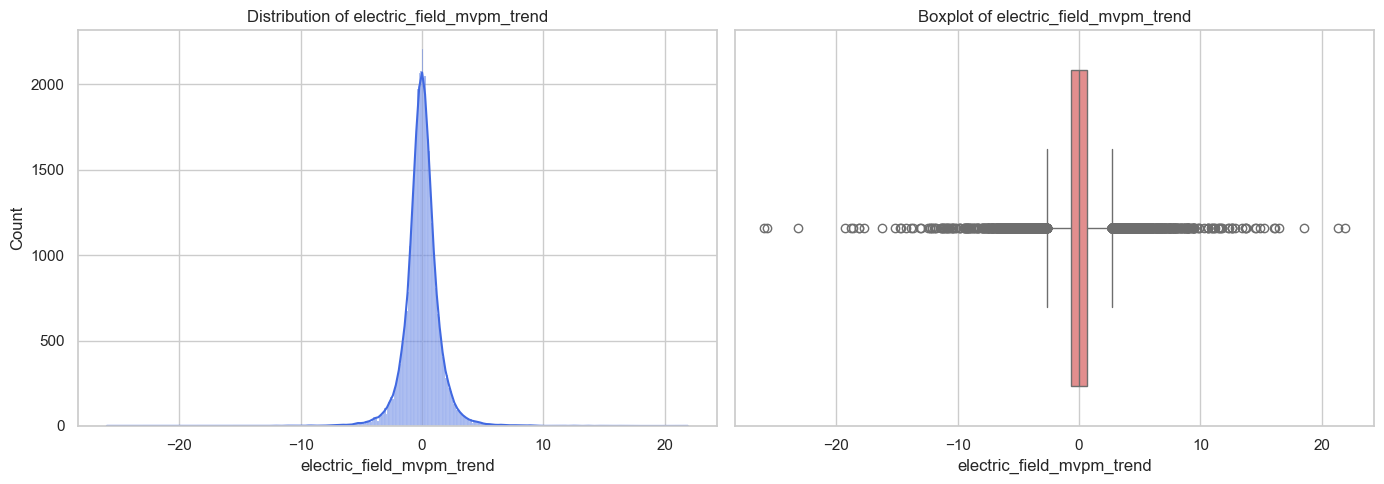

In [5]:
WIND_COLS = ["bz_gsm_nt", "b_magnitude_avg_nt", "flow_speed_kms",
             "proton_density_cm3", "flow_pressure_npa", "electric_field_mvpm"]
STATS = ["mean", "min", "max", "last", "trend"]

rolling_cols = [f"{c}_{s}" for c in WIND_COLS for s in STATS]

for col in rolling_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color="royalblue")
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[1], color="lightcoral")
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

**Observations:** The most heavily right-skewed features are all pressure/field-strength related — `flow_pressure_npa_last` (skew 5.5), `electric_field_mvpm_max` (4.9), `flow_pressure_npa_max` (4.5), `flow_pressure_npa_mean` (3.6) — consistent with solar wind dynamic pressure spiking sharply during CME/shock arrivals rather than varying smoothly. At the other extreme, `bz_gsm_nt_min` and `electric_field_mvpm_min` are strongly *negatively* skewed (-2.7, -3.4): "min" over a trailing window captures the rare-but-large southward-Bz / negative-E-field excursions — which is exactly the textbook geoeffective driver of storms, so it's reassuring to see it show up as the most extreme-tailed feature. The `_trend` columns cluster close to zero skew (0.1-0.5, two mildly negative), which is a good sanity check — they're differences across the window, so they should be roughly symmetric, and they are. On redundancy: `_mean` correlates ~0.64-0.65 with both `_min` and `_max` (expected, same underlying series), but `_min` and `_max` barely correlate with each other (-0.02) — so despite all coming from one quantity, min/max aren't redundant with *each other*, only each with the mean.

## 4. Event / Count Features
`flare_count_win`, `cme_count_win`, `flare_max_class_now`, and `cme_max_speed_now` are
sparse: most 3h bins have no flare or CME at all. Histograms/boxplots would just show a
spike at zero, so these get value-count tables and count plots instead.

--- flare_count_win ---
count    43817.000000
mean         2.772029
std          5.167082
min          0.000000
25%          0.000000
50%          0.000000
75%          4.000000
max         34.000000
Name: flare_count_win, dtype: float64
Zero rate: 67.02%

--- cme_count_win ---
count    43817.000000
mean         1.330420
std          1.718931
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         13.000000
Name: cme_count_win, dtype: float64
Zero rate: 42.89%

--- flare_max_class_now ---
count    43817.00000
mean         0.54367
std          1.16053
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          5.00000
Name: flare_max_class_now, dtype: float64
Zero rate: 81.02%

--- cme_max_speed_now ---
count    43817.000000
mean        77.808438
std        220.173444
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       3529.000000
Name: cme_max_speed_now, dtype:

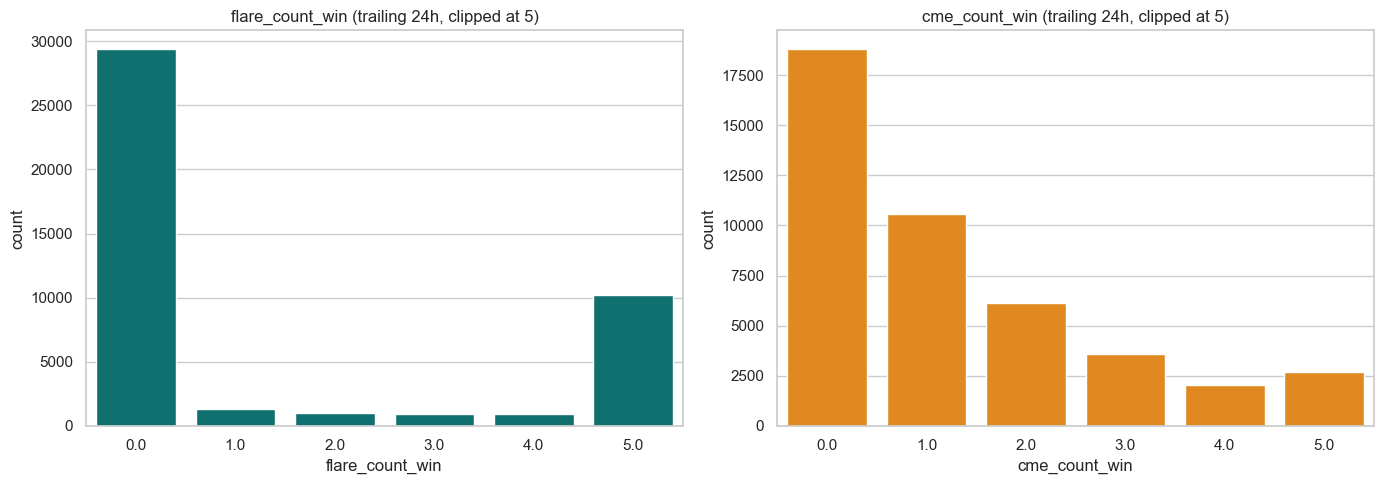

In [6]:
event_cols = ["flare_count_win", "cme_count_win", "flare_max_class_now", "cme_max_speed_now"]

for col in event_cols:
    print(f"--- {col} ---")
    print(df[col].describe())
    print(f"Zero rate: {(df[col] == 0).mean():.2%}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=df["flare_count_win"].clip(upper=5), ax=axes[0], color="teal")
axes[0].set_title("flare_count_win (trailing 24h, clipped at 5)")
sns.countplot(x=df["cme_count_win"].clip(upper=5), ax=axes[1], color="darkorange")
axes[1].set_title("cme_count_win (trailing 24h, clipped at 5)")
plt.tight_layout()
plt.show()

**Observations:** These features are as sparse as expected — `flare_count_win` is zero in 67% of bins, `cme_count_win` in 43%, and the "right now" snapshots are even sparser: `flare_max_class_now` is zero (no flare peaking in this exact bin) 81% of the time, `cme_max_speed_now` 86%. The class breakdown for `flare_max_class_now` is notable: 2,425 B-class bins, 4,668 C-class, 1,147 M-class, but only **76 X-class bins out of 43,817 (0.17%)** — the most severe flares are extremely rare, and there are zero A-class bins recorded at all in this feature. Multi-event bins do happen (`flare_count_win` maxes out at 34, `cme_count_win` at 13 in a 24h window — active regions cluster flares), but that's tail behavior, not typical. Given how zero-inflated these are, a binary "any event in window" flag might be a more robust signal for a model than the raw counts, which are mostly zero-variance noise outside the active tail.

## 5. Target Distribution (`ap_now` / `ap_target`)
This is the single most important section for anyone about to model this dataset: how
skewed is `ap`, and how rare are actual storms?

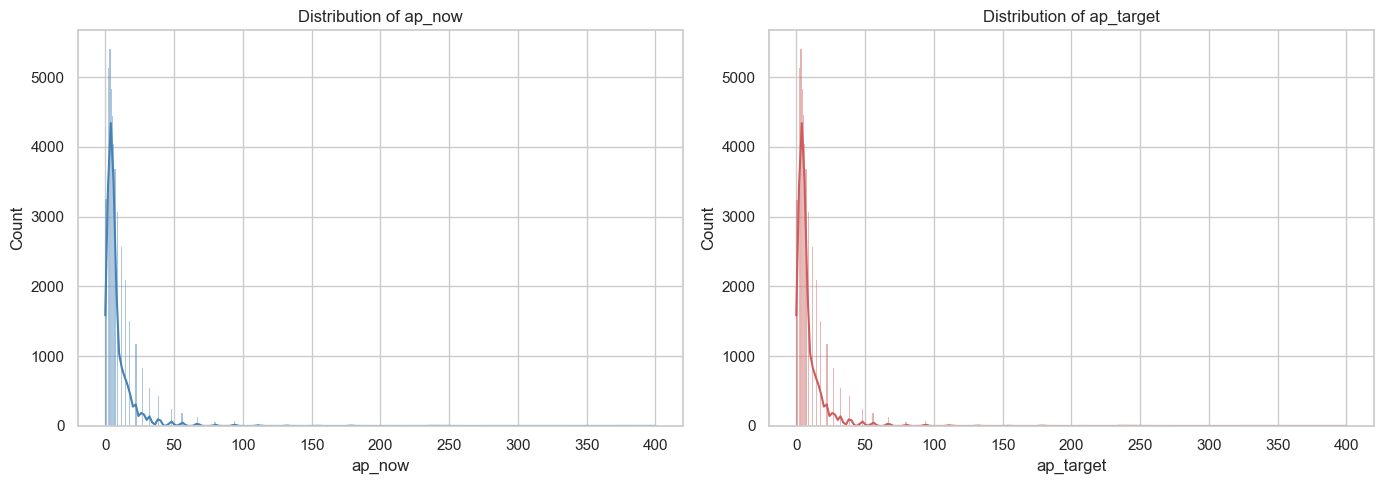

             ap_now     ap_target
count  43817.000000  43817.000000
mean       8.596549      8.597531
std       12.680833     12.680428
min        0.000000      0.000000
25%        3.000000      3.000000
50%        5.000000      5.000000
75%        9.000000      9.000000
max      400.000000    400.000000

Bins with ap_target > 50 (storm-level): 1.26%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["ap_now"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of ap_now")
sns.histplot(df["ap_target"], kde=True, ax=axes[1], color="indianred")
axes[1].set_title("Distribution of ap_target")
plt.tight_layout()
plt.show()

print(df[["ap_now", "ap_target"]].describe())

storm_threshold = 50
storm_rate = (df["ap_target"] > storm_threshold).mean()
print(f"\nBins with ap_target > {storm_threshold} (storm-level): {storm_rate:.2%}")

**Observations:** `ap_now` and `ap_target` have near-identical distributions (mean 8.6, median 5, std ~12.7, max 400) — expected, since `ap_target` is the same physical quantity just shifted forward in time. The mean sitting well above the median (8.6 vs 5) confirms this is heavily right-skewed: most of the time geomagnetic activity is quiet, punctuated by rare spikes. The imbalance gets more severe the higher the bar: `ap_target > 30` is 4.05% of bins, `> 50` (storm-level) is 1.26%, `> 100` (severe) is just 0.23%. For modeling, this means a plain regression optimized for MAE/MSE will be dominated by getting the "quiet" majority right and largely ignore storm bins — worth considering a log1p transform on the target, a storm-weighted loss, or reframing the problem as storm classification (binary or multiclass by severity) if the actual goal is alerting rather than exact `ap` value.

## 6. Temporal Trends
Geomagnetic activity tracks the ~11-year solar cycle. We look at the monthly maximum
`ap_target` across the full 2010-2024 span to see whether that cycle is visible.

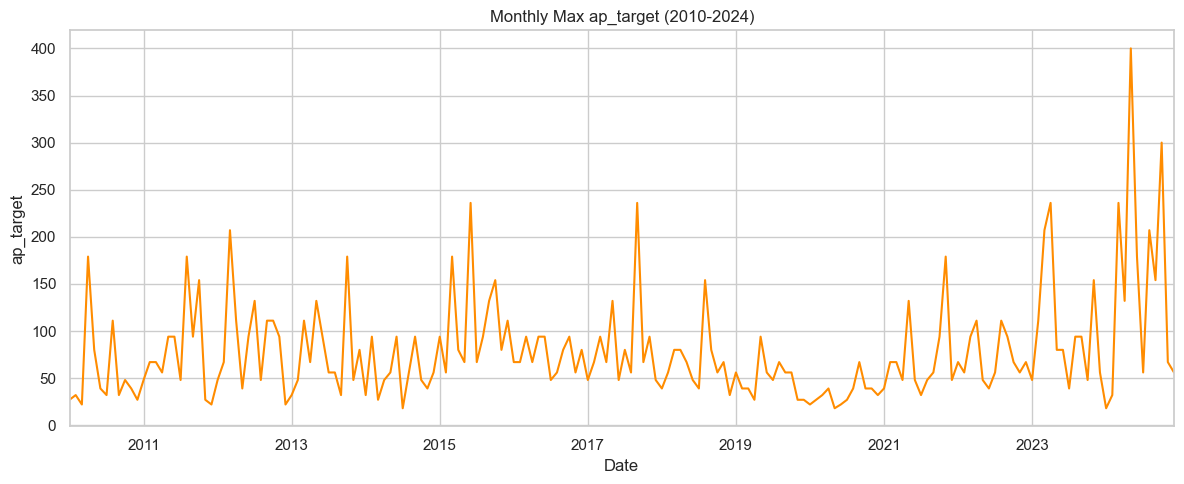

In [8]:
monthly_max_ap = df["ap_target"].resample("MS").max()

plt.figure(figsize=(12, 5))
monthly_max_ap.plot(color="darkorange")
plt.title("Monthly Max ap_target (2010-2024)")
plt.ylabel("ap_target")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

**Observations:** The 11-year solar cycle is visible in the yearly *mean* `ap_target`, and it lines up with known solar-cycle history: the lowest yearly mean in the whole dataset is 2020 (5.25), with 2019 close behind (6.07) — matching Solar Cycle 24's minimum. Activity then climbs steadily through 2021 (7.2) → 2022 (10.1) → 2023 (10.8) → 2024 (11.7, the highest yearly mean in the span) as Solar Cycle 25 ramps toward its 2024-2025 maximum — this is a nice independent sanity check that the panel reflects real physics, not an artifact of the binning pipeline. The yearly *max*, though, doesn't track the cycle nearly as cleanly: 2024 contains the single largest value in the dataset (400 — almost certainly the May 2024 "Gannon" superstorm), but otherwise extreme spikes (236 in 2015, 2017, and 2023; 207 in 2012) don't line up neatly with cycle phase — extreme individual storms are more stochastic than the average activity level. No months fall below 90% of expected bin coverage, confirming the grid-completeness result from Section 2 holds throughout, not just in aggregate.

## 7. Feature Correlations
A full 36x36 heatmap of every column is too dense to read at a glance, so we look at it
two ways: the full matrix for completeness, then a reduced matrix of just the current-bin
(`_now`/`_mean`) features against `ap_target` — the relationships that actually matter for
predicting the target.

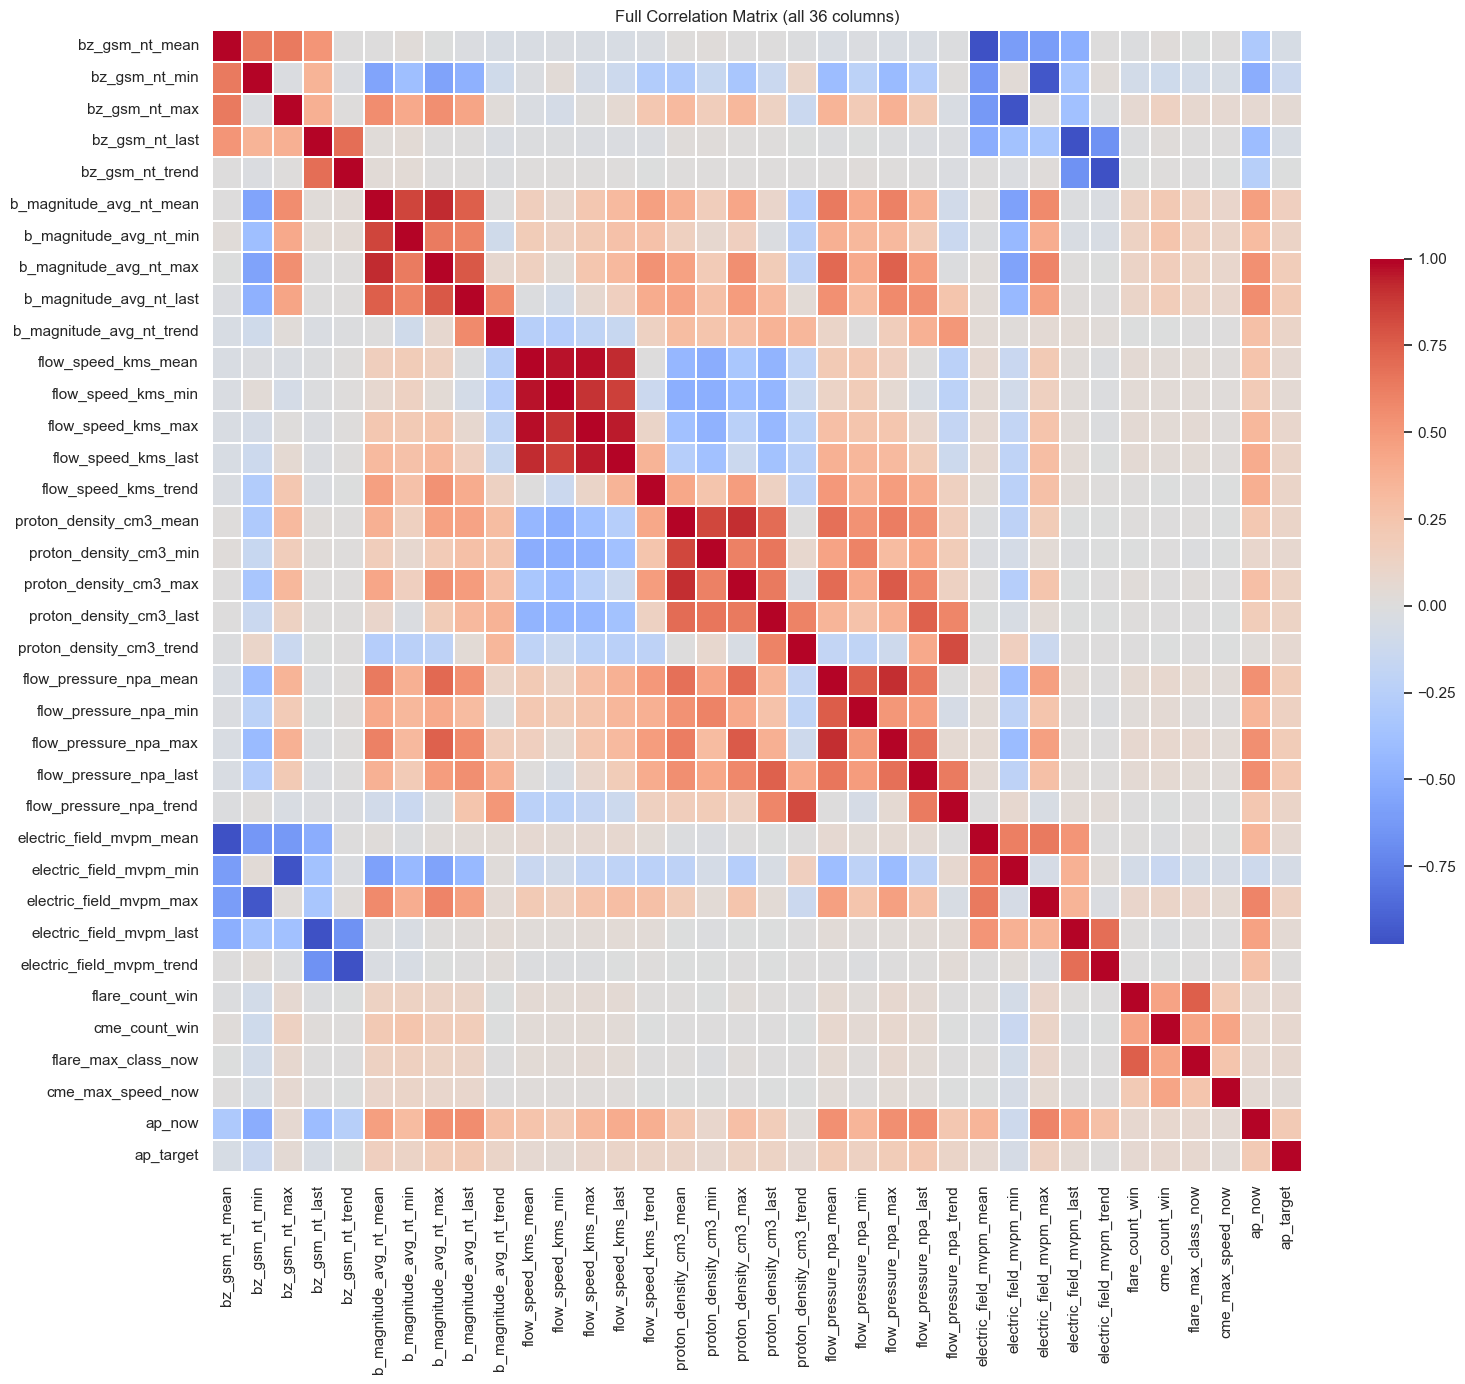

In [9]:
plt.figure(figsize=(16, 14))
corr_full = df.corr()
sns.heatmap(corr_full, cmap="coolwarm", center=0, linewidths=0.3, cbar_kws={"shrink": 0.6})
plt.title("Full Correlation Matrix (all 36 columns)")
plt.tight_layout()
plt.show()

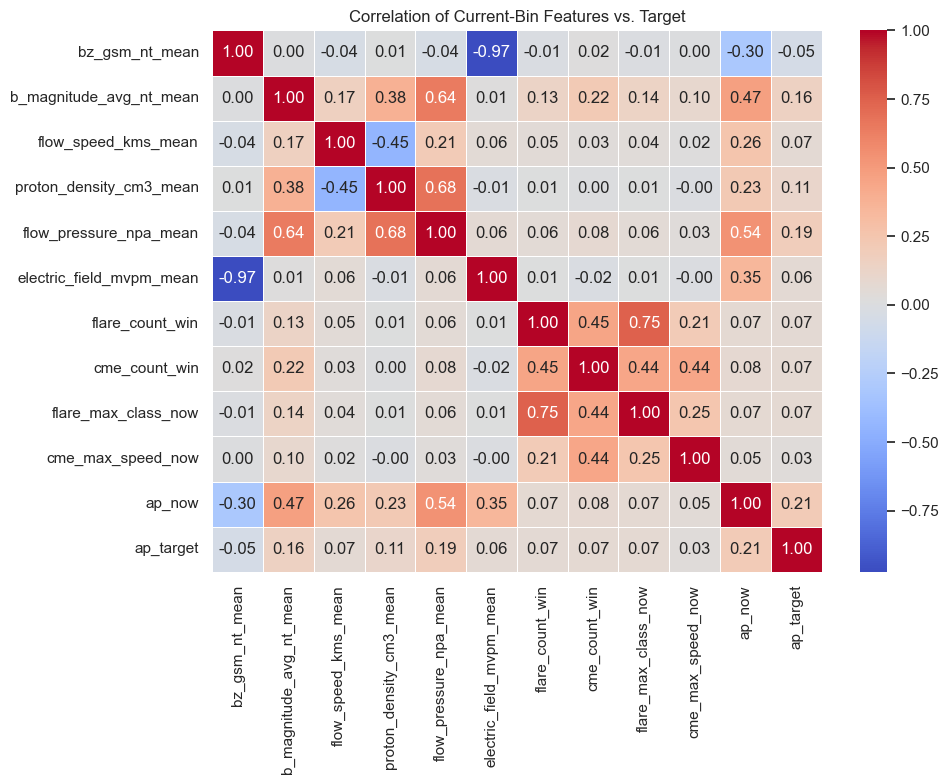

In [10]:
reduced_cols = [f"{c}_mean" for c in WIND_COLS] + event_cols + ["ap_now", "ap_target"]

plt.figure(figsize=(10, 8))
corr_reduced = df[reduced_cols].corr()
sns.heatmap(corr_reduced, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation of Current-Bin Features vs. Target")
plt.tight_layout()
plt.show()

**Observations:** The strongest linear correlations with `ap_target` are `flow_pressure_npa_last` (0.222), `ap_now` (0.209 — the persistence signal), `b_magnitude_avg_nt_last` (0.207), `flow_pressure_npa_mean` (0.187), and `flow_pressure_npa_max` (0.186); `bz_gsm_nt_min` is the top *negative* correlate (-0.126). Two things stand out. First, no single feature clears ~0.22 — nothing here is strongly linearly predictive on its own, which matches the build notebook's finding that even the persistence baseline has a negative R² for 24h-ahead forecasting: this is a genuinely weak-linear-signal problem. Second, dynamic pressure and field *magnitude* dominate the top correlations more than mean Bz does, which is a little surprising given Bz-driven reconnection is the textbook geoeffective driver — likely because that relationship is threshold/nonlinear (only strongly negative Bz excursions matter, captured better by `_min` than `_mean`), so a linear correlation understates it and a nonlinear model (random forest / gradient boosting) should pick up more signal than this table suggests. The reduced heatmap also reconfirms the Section 3 redundancy: `flow_pressure_npa_mean/_last/_max` visibly co-move, so a feature-selection pass should thin the 5-stats-per-quantity design rather than feed all 30 in as-is.

## 8. Key Takeaways & Next Steps

* **Data Quality**: The 3h grid is fully regular over 2010-2024 (0 duplicate timestamps, 0 missing bins), so the underlying resampling is sound. Small null pockets remain (up to 186/43,817 rows, or 0.4%, worst in `proton_density_cm3`/`flow_pressure_npa` and in the `_trend` columns specifically) — these should be dropped or imputed, but they're not a red flag about the build process.
* **Distributions**: Pressure- and field-magnitude features are the most right-skewed (skew up to 5.5) — likely candidates for a log/Box-Cox transform. `bz_gsm_nt_min` and `electric_field_mvpm_min` are strongly left-skewed, which is a good sign: they're capturing the rare, large southward-Bz excursions that physically drive storms. `_trend` features are close to symmetric, as they should be.
* **Sparsity**: Flare/CME count and intensity features are heavily zero-inflated (67-86% zero), with X-class flares appearing in only 0.17% of bins. A binary "any event" flag may generalize better than raw counts given how thin the non-zero tail is.
* **Class Imbalance**: `ap_target` is right-skewed (mean 8.6 vs. median 5), and storm-level bins (`ap_target > 50`) are only 1.26% of the data (0.23% for severe storms, `>100`). Plain MAE/MSE regression will be dominated by the quiet majority — worth a log1p target transform, weighted loss, or reframing as storm classification depending on the end goal.
* **Correlations**: No single feature exceeds ~0.22 linear correlation with `ap_target` (top: `flow_pressure_npa_last`, `ap_now`, `b_magnitude_avg_nt_last`) — this is a weak-linear-signal forecasting problem, consistent with the build notebook's negative-R² persistence baseline. Mean Bz correlates less than expected given the physics; this smells like a nonlinear/threshold effect that tree-based models should capture better than linear correlation suggests. The yearly trend in mean `ap_target` visibly tracks the solar cycle (2019-2020 minimum, rising into 2024), a good independent sanity check on the data.
* **Next Steps**: (1) Thin the redundant `_mean/_min/_max/_last/_trend` groups via feature selection or PCA rather than feeding all 30 rolling columns in raw. (2) Try nonlinear models (random forest/gradient boosting) given the weak linear correlations but physically-motivated nonlinear relationships (esp. Bz). (3) Address the storm-class imbalance explicitly — this dataset alone won't reward a model that just predicts the mean. (4) Compare against the persistence baseline already computed in `notebooks/time_binned_dataset.ipynb` — that's the real bar to beat, not zero.